In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
import yaml
import time
from itertools import combinations
import gget
from scipy.stats import zscore
import matplotlib.patches as patches

from pycirclize import Circos
from pycirclize.parser import Matrix
from pycirclize.utils import ColorCycler

from matplotlib_venn import venn3_unweighted
from matplotlib_venn import venn2_unweighted
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# import scvi
# from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

# Load in data

In [2]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 7.72 s, sys: 1.31 s, total: 9.04 s
Wall time: 9.14 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [3]:
fpath = "../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")

idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])

transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

print(f"N unique uniprot IDs: {idf['uniprot'].nunique()}")
idf.head()

idf.shape=(110149, 11)
N unique uniprot IDs: 73747


,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
0,ENSG00000198888,ENSG00000198888.2,ENST00000361390,ENST00000361390.2,ENSP00000354687,ENSP00000354687.2,956,MT-ND1-201,MT-ND1,P03886,U5Z754,U5Z754
1,ENSG00000198763,ENSG00000198763.3,ENST00000361453,ENST00000361453.3,ENSP00000355046,ENSP00000355046.4,1042,MT-ND2-201,MT-ND2,P03891,Q7GXY9,Q7GXY9
2,ENSG00000198804,ENSG00000198804.2,ENST00000361624,ENST00000361624.2,ENSP00000354499,ENSP00000354499.2,1542,MT-CO1-201,MT-CO1,P00395,U5YWV7,U5YWV7
3,ENSG00000198712,ENSG00000198712.1,ENST00000361739,ENST00000361739.1,ENSP00000354876,ENSP00000354876.1,684,MT-CO2-201,MT-CO2,P00403,U5Z487,U5Z487
4,ENSG00000228253,ENSG00000228253.1,ENST00000361851,ENST00000361851.1,ENSP00000355265,ENSP00000355265.1,207,MT-ATP8-201,MT-ATP8,P03928,U5YV54,U5YV54


In [45]:
idf[idf['Gene name'] == 'TEAD4']

,Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Protein stable ID,Protein stable ID version,Transcript length (including UTRs and CDS),Transcript name,Gene name,UniProtKB/Swiss-Prot ID,UniProtKB/TrEMBL ID,uniprot
102342,ENSG00000197905,ENSG00000197905.10,ENST00000358409,ENST00000358409.7,ENSP00000351184,ENSP00000351184.3,1637,TEAD4-201,TEAD4,Q15561,A0A0A0MRF3,A0A0A0MRF3
102346,ENSG00000197905,ENSG00000197905.10,ENST00000359864,ENST00000359864.8,ENSP00000352926,ENSP00000352926.3,1710,TEAD4-202,TEAD4,Q15561,Q53GI4,Q53GI4
102348,ENSG00000197905,ENSG00000197905.10,ENST00000540314,ENST00000540314.2,ENSP00000438960,ENSP00000438960.2,578,TEAD4-206,TEAD4,NaN,H0YFK0,H0YFK0
102349,ENSG00000197905,ENSG00000197905.10,ENST00000536826,ENST00000536826.2,ENSP00000438453,ENSP00000438453.2,570,TEAD4-205,TEAD4,NaN,H0YFF9,H0YFF9
102350,ENSG00000197905,ENSG00000197905.10,ENST00000543035,ENST00000543035.6,ENSP00000444528,ENSP00000444528.2,801,TEAD4-207,TEAD4,NaN,H0YGS2,H0YGS2
102351,ENSG00000197905,ENSG00000197905.10,ENST00000397122,ENST00000397122.6,ENSP00000380311,ENSP00000380311.2,1396,TEAD4-203,TEAD4,Q15561,NaN,Q15561
102353,ENSG00000197905,ENSG00000197905.10,ENST00000443986,ENST00000443986.3,ENSP00000411475,ENSP00000411475.3,641,TEAD4-204,TEAD4,NaN,H0Y7B0,H0Y7B0
102354,ENSG00000197905,ENSG00000197905.10,ENST00000544666,ENST00000544666.1,ENSP00000441959,ENSP00000441959.1,567,TEAD4-208,TEAD4,NaN,H0YG62,H0YG62


In [4]:
upath = "/scratch/indikar_root/indikar1/jrcwycy/hsc_temp/HUMAN_9606_idmapping_selected.tab.gz"

columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    'GeneID (EntrezGene)',
    'RefSeq',
    'GI',
    'PDB',
    'GO',
    'UniRef100',
    'UniRef90',
    'UniRef50',
    'UniParc',
    'PIR',
    'NCBI-taxon',
    'MIM',
    'UniGene',
    'PubMed',
    'EMBL',
    'EMBL-CDS',
    'Ensembl',
    'Ensembl_TRS',
    'Ensembl_PRO',
    'Additional PubMed',
]

udf = pd.read_csv(
    upath, 
    sep='\t',
    header=None,
    low_memory=False,
    names=columns,
)

keep_columns = [
    'UniProtKB-AC',
    'UniProtKB-ID',
    # 'Ensembl',
    'Ensembl_TRS',
]

udf = udf[keep_columns]
udf = udf.assign(Ensembl_TRS=udf['Ensembl_TRS'].str.split(';')).explode('Ensembl_TRS')
udf['transcript_id'] = udf['Ensembl_TRS'].apply(lambda x: str(x).split(".")[0])
udf = udf.rename(columns={'UniProtKB-AC': 'uniprot'})

transcript_map = dict(zip(udf['transcript_id'].values, udf['uniprot'].values))

print(f"N unique uniprot IDs: {udf['uniprot'].nunique()}")
udf.head()

N unique uniprot IDs: 205003


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703
0,P31946,1433B_HUMAN,ENST00000372839.7,ENST00000372839
1,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335
1,P62258,1433E_HUMAN,ENST00000571732.5,ENST00000571732
1,P62258,1433E_HUMAN,ENST00000616643.3,ENST00000616643


In [5]:
gtf_sub = gtf[['transcript_id', 'transcript_name']].drop_duplicates()
gtf_sub = gtf_sub.dropna()
print(gtf_sub.shape)
gtf_sub.head()

udf1 = pd.merge(udf, gtf_sub, how='left', on='transcript_id')
print(udf1.shape)

udf1 = udf1.dropna(subset='transcript_name')

print(udf1.shape)
print(f"N unique uniprot IDs: {udf1['uniprot'].nunique()}")


transcript_map = dict(zip(udf1['transcript_name'].values, udf1['uniprot'].values))

udf1.head()

(226005, 2)
(246523, 5)
(78415, 5)
N unique uniprot IDs: 78415


,uniprot,UniProtKB-ID,Ensembl_TRS,transcript_id,transcript_name
0,P31946,1433B_HUMAN,ENST00000353703.9,ENST00000353703,YWHAB-201
2,P62258,1433E_HUMAN,ENST00000264335.13,ENST00000264335,YWHAE-201
6,Q04917,1433F_HUMAN,ENST00000248975.6,ENST00000248975,YWHAH-201
7,P61981,1433G_HUMAN,ENST00000307630.5,ENST00000307630,YWHAG-201
8,P31947,1433S_HUMAN,ENST00000339276.6,ENST00000339276,SFN-201


In [6]:
fpath = "../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [7]:
%%time
fpath = "/scratch/indikar_root/indikar1/shared_data/hematokytos/new_processed/isoforms.h5ad"
adata = sc.read_h5ad(fpath)

adata.var['uniprot'] = adata.var.index.map(transcript_map)

adata

CPU times: user 1.24 s, sys: 526 ms, total: 1.76 s
Wall time: 4.06 s


AnnData object with n_obs × n_vars = 20754 × 113335
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot'
    uns: 'label_colors', 'label_deg', 'scvi_expression'
    obsm: 'X_umap'

# Process adata

In [8]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
adata.layers['norm'] = adata.X.copy()

rsc.pp.log1p(adata)

rsc.get.anndata_to_CPU(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43994 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 20754 × 69341
    obs: 'dataset', 'source', 'label', 'cluster_all', 'group', 'subgroup', 'phase', 'S_score', 'G2M_score'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot', 'n_counts', 'n_cells'
    uns: 'label_colors', 'label_deg', 'scvi_expression', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'norm', 'log_norm'

In [9]:
# regroup
mapping = {
    'CLP': 'progenitors', 
    'LMPP': 'progenitors', 
}

adata.obs['subgroup'] = adata.obs['subgroup'].astype(str)

adata.obs['subgroup'] = adata.obs['subgroup'].replace(mapping)

adata.obs['subgroup'].value_counts()

subgroup
initial        8464
R2             4323
progenitors    3952
R1             1985
HSC            1506
R3              524
Name: count, dtype: int64

# Get iso counts

In [27]:
%%time 

adata.X = adata.layers['counts'].copy()
# adata.X = adata.layers['log_norm'].copy()

rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

aggdata = rsc.get.aggregate(
    adata, 
    by='subgroup',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(aggdata, convert_all=True,)

aggdata.X = aggdata.layers['sum'].copy()

sc.pp.normalize_total(aggdata, target_sum=1e6)
aggdata.layers['norm'] = aggdata.X.copy()

sc.pp.log1p(aggdata)

aggdata.layers['log_norm'] = aggdata.X.copy()

aggdata

# df = aggdata.to_df(layer='sum')
# df = aggdata.to_df(layer='log_norm')
df = aggdata.to_df(layer='norm')
df = df.T
df['total_transcript'] = df.sum(axis=1)

df = pd.merge(
    df, adata.var[['gene_name', 'gene_type', 'transcript_type']],
    how='left',
    left_index=True,
    right_index=True,
)
df = df.reset_index()
df = df.sort_values(by=['gene_name', 'transcript_name'])
df = df.reset_index(drop=True)
df['is_tf'] = df['gene_name'].isin(tf_list)
# df['uniprot'] = df['transcript_name'].map(transcript_2_uniprot)
df['uniprot'] = df['transcript_name'].map(transcript_map) # new mapping
print(f"{df.shape=}")
df.head()

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
normalizing counts per cell
    finished (0:00:00)
df.shape=(69341, 13)
CPU times: user 151 ms, sys: 13.8 ms, total: 165 ms
Wall time: 173 ms


,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,transcript_type,is_tf,uniprot
0,A1BG-202,0.399097,0.655344,0.770458,0.881711,0.105057,0.447956,3.259624,A1BG,protein_coding,retained_intron,False,NaN
1,A1BG-203,0.532130,2.348317,2.043388,1.763423,0.345187,0.534101,7.566547,A1BG,protein_coding,protein_coding_CDS_not_defined,False,NaN
2,A1BG-204,41.772184,225.984578,194.657853,125.864298,112.861215,50.119390,751.259518,A1BG,protein_coding,retained_intron,False,NaN
3,A1BG-AS1-202,2.727165,0.819180,0.267985,0.661284,0.615334,2.653278,7.744226,A1BG-AS1,lncRNA,lncRNA,False,NaN
4,A1BG-AS1-203,0.000000,0.273060,0.368480,0.000000,0.330179,0.034458,1.006177,A1BG-AS1,lncRNA,lncRNA,False,NaN


In [28]:
%%time
pdf = df.copy()

# count the number of isoforms per gene
pdf['n_isoforms'] = pdf.groupby('gene_name')['transcript_name'].transform('nunique')
pdf['n_protiens'] = pdf.groupby('gene_name')['uniprot'].transform('nunique')

groups = ['R1','R2', 'R3', 'initial', 'HSC']

# add grouped expression counts
grouped = pdf.groupby('gene_name')[groups].sum()
sum_columns  = [f'{col}_sum' for col in grouped.columns]
grouped.columns = sum_columns
pdf = pdf.merge(grouped, on='gene_name', how='left')

pdf['total_gene'] = pdf[sum_columns].sum(axis=1)

# add percentages
for col in groups:
    sum_col = f'{col}_sum'
    pct_col = f'{col}_pct'
    pdf[pct_col] = pdf[col] / pdf[sum_col]

print(pdf[['gene_name', 'transcript_name', 'R1_pct', 'R2_pct', 'R3_pct']].head().to_string())

  gene_name transcript_name    R1_pct    R2_pct    R3_pct
0      A1BG        A1BG-202  0.002862  0.003902  0.006861
1      A1BG        A1BG-203  0.010255  0.010348  0.013722
2      A1BG        A1BG-204  0.986883  0.985751  0.979417
3  A1BG-AS1    A1BG-AS1-202  0.137615  0.047619  0.120000
4  A1BG-AS1    A1BG-AS1-203  0.045872  0.065476  0.000000
CPU times: user 46 ms, sys: 0 ns, total: 46 ms
Wall time: 47.5 ms


# Top isoforms

In [29]:
def get_top(df, col):
    # Remove groups with any NaN
    mask = df.groupby('gene_name', observed=True)[col].transform(lambda x: x.isna().any())
    df_valid = df[~mask]

    # Get index of max value per group
    top_idx = df_valid.groupby('gene_name', observed=True)[col].idxmax()
    counts = df_valid.groupby('gene_name', observed=True)[col].apply(lambda x: (x == x.max()).sum())

    # Build mapping and drop ties
    top_map = df_valid.loc[top_idx, ['gene_name', 'transcript_name']].set_index('gene_name')['transcript_name']
    top_map[counts > 1] = np.nan

    return df['gene_name'].map(top_map)

pct_cols = ['R1_pct', 'R2_pct', 'R3_pct', 'initial_pct', 'HSC_pct']

for col in pct_cols:
    pdf[f'{col}_top'] = get_top(pdf, col)

pdf.head()

,transcript_name,HSC,R1,R2,R3,initial,progenitors,total_transcript,gene_name,gene_type,...,R1_pct,R2_pct,R3_pct,initial_pct,HSC_pct,R1_pct_top,R2_pct_top,R3_pct_top,initial_pct_top,HSC_pct_top
0,A1BG-202,0.399097,0.655344,0.770458,0.881711,0.105057,0.447956,3.259624,A1BG,protein_coding,...,0.002862,0.003902,0.006861,0.000927,0.009346,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
1,A1BG-203,0.532130,2.348317,2.043388,1.763423,0.345187,0.534101,7.566547,A1BG,protein_coding,...,0.010255,0.010348,0.013722,0.003046,0.012461,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
2,A1BG-204,41.772184,225.984578,194.657853,125.864298,112.861215,50.119390,751.259518,A1BG,protein_coding,...,0.986883,0.985751,0.979417,0.996026,0.978193,A1BG-204,A1BG-204,A1BG-204,A1BG-204,A1BG-204
3,A1BG-AS1-202,2.727165,0.819180,0.267985,0.661284,0.615334,2.653278,7.744226,A1BG-AS1,lncRNA,...,0.137615,0.047619,0.120000,0.157692,0.546667,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202
4,A1BG-AS1-203,0.000000,0.273060,0.368480,0.000000,0.330179,0.034458,1.006177,A1BG-AS1,lncRNA,...,0.045872,0.065476,0.000000,0.084615,0.000000,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-209,A1BG-AS1-204,A1BG-AS1-202


# Proportion plot

Text(0.5, 1.0, 'COL5A1')

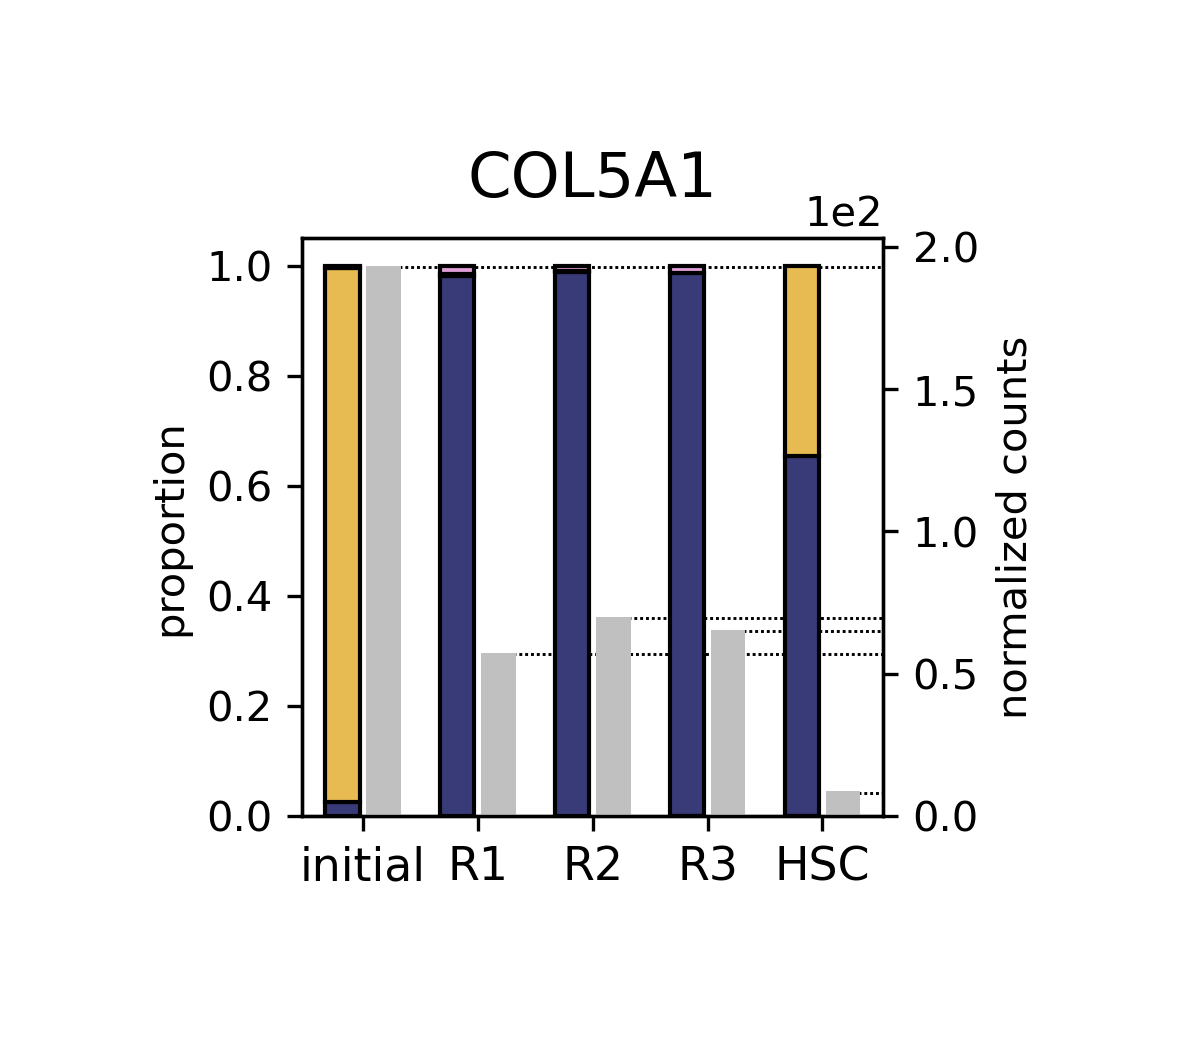

In [43]:
query = 'COL5A1'
width = 0.3
nudge = 0.03
color = 'silver'


"""
DATA SET UP
"""
plot_df = pdf.copy()
plot_df = plot_df[plot_df['gene_name'] == query]

plot_df = plot_df.sort_values(by='transcript_name')

# Add uniprot 
plot_df['annotation'] = (
    plot_df['transcript_name']
    + np.where(
        plot_df['uniprot'].notna(),
        ' (' + plot_df['uniprot'] + ')',
            ''
        )
    )


plot_df = plot_df.set_index('annotation')

# get total counts for the gene
counts = plot_df[['initial', 'R1', 'R2', 'R3', 'HSC']].sum(axis=0)

# get transcript percentages
plot_df = plot_df[['initial_pct', 'R1_pct', 'R2_pct', 'R3_pct', 'HSC_pct']]
plot_df = plot_df[plot_df.sum(axis=1) != 0] # drop zero-sum transcripts !

plot_df.columns = plot_df.columns.map(lambda x: x.split("_")[0])
plot_df = plot_df.T
plot_df

"""
PLOT
"""
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, 2.5 # 2.75, 3
fig, ax1 = plt.subplots()

# Create a second axis for the count bar plot
ax2 = ax1.twinx()

ax2.bar(
    counts.index, 
    counts.values, 
    color=color, 
    # ec='k',
    alpha=1,
    width=width,
    # linewidth=1,
    zorder=4,
    align='edge',
)

ax2.set_ylabel("normalized counts", color='k')
ax2.tick_params(axis='y', color='k', labelcolor='k', )

# line_nudge = 0.1
line_nudge = 0.0025 * ax2.get_ylim()[1]

# Add reference lines
for i, count in enumerate(counts.values):
    if count > 0:
        ax2.plot(
            # [i + 0.2, 5], 
            [i + width + 0.01, 5],
            [count - line_nudge, count - line_nudge], 
            color='k',
            linestyle='--',
            dashes=(1, 1),
            lw=0.7,
            zorder=2,
        )

# plot_df.columns = [x.split("-")[1] for x in plot_df.columns]
    
plot_df.plot(
    kind='bar',
    stacked=True,
    ec='k',
    cmap='tab20b',
    linewidth=1,
    width=-width,
    ax=ax1,
    zorder=5,
    align='edge',
    legend=False,
)

ax1.set_zorder(ax2.get_zorder()+1)
ax1.patch.set_visible(False)
# ax1.set_xlim([-.5 - nudge, 2.5 + nudge])
ax1.set_xlim([-.5 - nudge, len(plot_df.index) - 0.5 + nudge])

ax1.tick_params(axis='x', rotation=0, labelsize=11)
ax1.set_ylabel(f"proportion")
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# get legend info
handles, labels = ax1.get_legend_handles_labels()

# Shift bars to the left
bar_positions = [bar.get_x() for bar in ax1.patches]
new_positions = [pos - nudge for pos in bar_positions] 
for bar, new_pos in zip(ax1.patches, new_positions):
    bar.set_x(new_pos)
    
# Shift bars to the right
bar_positions = [bar.get_x() for bar in ax2.patches]
new_positions = [pos + nudge for pos in bar_positions] 
for bar, new_pos in zip(ax2.patches, new_positions):
    bar.set_x(new_pos)
        
# sns.move_legend(
#     ax1,
#     loc='lower center',
#     title="",
#     frameon=False,
#     bbox_to_anchor=(0.5, -0.74),
#     fontsize='small',
#     ncol=2,
# )

plt.title(query, fontsize=15, pad=10)

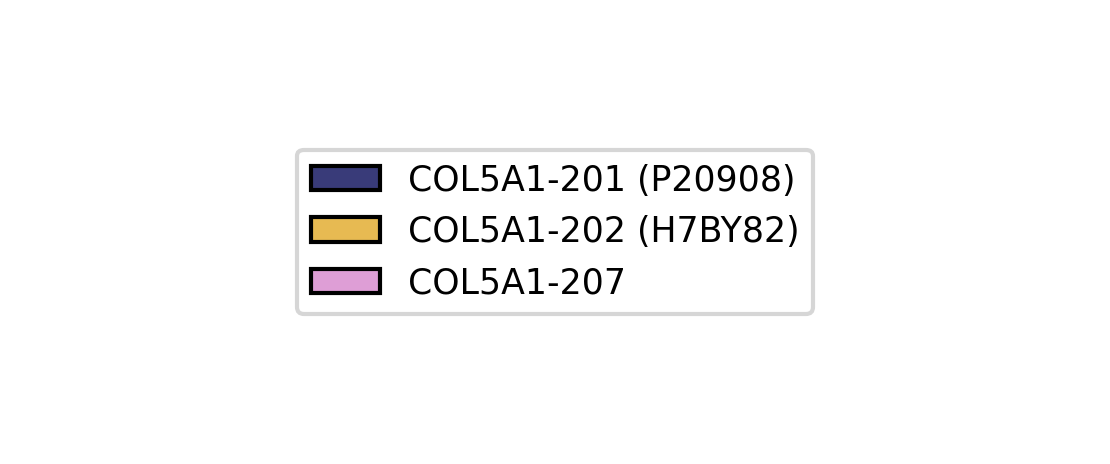

In [44]:
fig_leg, ax_leg = plt.subplots(figsize=(3,0.5))  # Adjust width/height as needed
ax_leg.legend(
    handles,
    labels,
    loc='center',
    ncol=1,
    # frameon=False,
    fontsize='small',
)
ax_leg.axis('off')

plt.tight_layout()
plt.show()

In [46]:
adata.X = adata.layers["counts"].copy()

rsc.get.anndata_to_GPU(adata)
print(f"{type(adata.X)=}")

bdata = rsc.get.aggregate(
    adata, 
    by='subgroup',
    func='sum',
    axis=0,
)

rsc.get.anndata_to_CPU(bdata, convert_all=True,)

print(bdata.shape)

bdata.X = bdata.layers['sum'].copy()

sc.pp.normalize_total(bdata, target_sum=1e6)
bdata.layers['norm'] = bdata.X.copy()

sc.pp.log1p(bdata)

bdata.layers['log_norm'] = bdata.X.copy()
bdata

type(adata.X)=<class 'cupyx.scipy.sparse._csr.csr_matrix'>
(6, 69341)
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 6 × 69341
    obs: 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'uniprot', 'n_counts', 'n_cells'
    uns: 'log1p'
    layers: 'sum', 'norm', 'log_norm'

genes to plot

COL5A1
#ELN
FLNA
#FLNC

CD63

RACK1

NOTCH1

TEAD1
TEAD4

Maybe LMNA

IL1R1 (z-score)
ARHGAP29 (z-score)

In [117]:
def get_transcripts(query, adata=adata):
    df = adata.var[adata.var['gene_name'] == query].copy()
    columns = [
        'gene_name',
        'gene_type',
        'transcript_name',
        'transcript_type',
        'uniprot',
    ]
    df = df[columns]
    return df


query = 'ARHGAP29'

label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()



cond_order = ['initial', 'R1', 'R2', 'R3', 'HSC']
    
pdata = bdata[cond_order, color].copy()
print(pdata.shape)

df = pdata.to_df()
display(df.head())

# get total counts per transcript
transcript_totals = df.sum(axis=0)
# get total gene counts 
gene_total = transcript_totals.sum()
# compute fraction of gene counts per transcript
transcript_frac = transcript_totals / gene_total

# apply threshold to filter for highly expressed transcripts
p = 0.1
keep_transcripts = transcript_frac[transcript_frac > p].index

df_filt = df[keep_transcripts]
display(df_filt)

# compute gene-wise z-score
df_z = df_filt.apply(zscore, axis=0)
df_z.head()

gene_name      gene_type transcript_name                transcript_type uniprot
 ARHGAP29 protein_coding    ARHGAP29-201                 protein_coding  Q52LW3
 ARHGAP29 protein_coding    ARHGAP29-202                 protein_coding     NaN
 ARHGAP29 protein_coding    ARHGAP29-203 protein_coding_CDS_not_defined     NaN
 ARHGAP29 protein_coding    ARHGAP29-204                retained_intron     NaN
 ARHGAP29 protein_coding    ARHGAP29-205        nonsense_mediated_decay  F8VWZ8
(5, 5)


transcript_name,ARHGAP29-201,ARHGAP29-202,ARHGAP29-203,ARHGAP29-204,ARHGAP29-205
initial,0.504046,0.312581,0.019764,0.001050,0.011193
R1,0.505657,0.120262,0.057823,0.005446,0.005446
R2,0.637310,0.119819,0.115053,0.016940,0.005345
R3,0.663320,0.152996,0.110491,0.013139,0.008778
HSC,0.000000,0.011902,0.000000,0.000000,0.000000


transcript_name,ARHGAP29-201,ARHGAP29-202
initial,0.504046,0.312581
R1,0.505657,0.120262
R2,0.637310,0.119819
R3,0.663320,0.152996
HSC,0.000000,0.011902


transcript_name,ARHGAP29-201,ARHGAP29-202
initial,0.174798,1.742009
R1,0.181507,-0.239560
R2,0.729698,-0.244121
R3,0.838002,0.097722
HSC,-1.924005,-1.356051


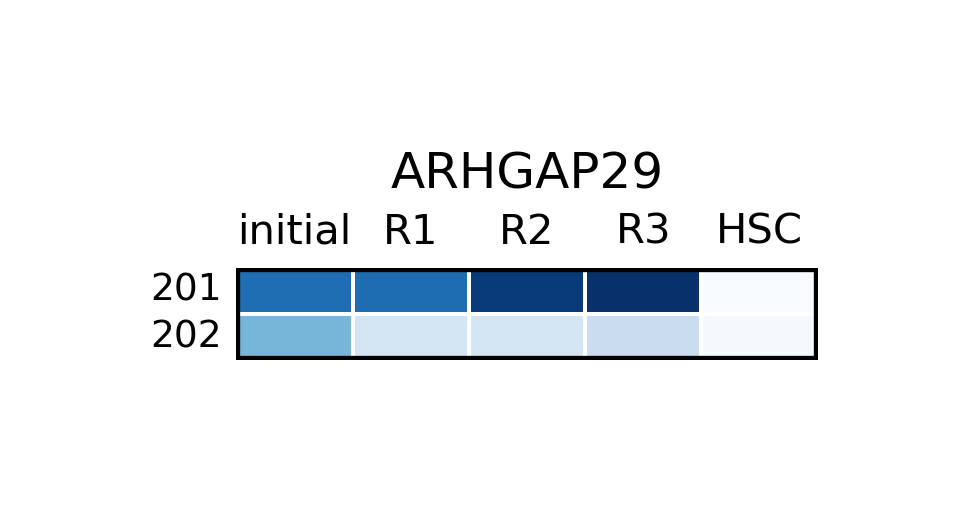

In [118]:
df_filt.columns = df_filt.columns.str.split('-').str[-1]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, len(df_filt.columns) * 0.2 #2.5

fig, ax = plt.subplots()

sns.heatmap(
    df_filt.T,
    cmap='Blues',
    lw=0.5,
    linecolor='white',
    cbar=False,
    # cbar_kws={'label':'expression', 'shrink': 0.6, 'pad': 0.05},
    ax=ax,
)

plt.ylabel("")

n_rows, n_cols = df_filt.shape
ax.set_yticks(np.arange(n_cols) + 0.5)
ax.set_yticklabels(df_filt.columns, rotation=0, fontsize=9)

ax.set_xticks(np.arange(len(cond_order)) + 0.5)
ax.set_xticklabels(cond_order)
# ax.set_xticklabels([label_map.get(g, g) for g in cond_order])

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.tick_params(axis='both', bottom=False, left=False, top=False, pad=0.05)

ax.set_title(f"{query}")

# Add black box around matrix
n_rows, n_cols = df_filt.T.shape
rect = patches.Rectangle(
    (0, 0), n_cols, n_rows,
    linewidth=2, edgecolor='black', facecolor='none', zorder=10
)
ax.add_patch(rect)

plt.show()

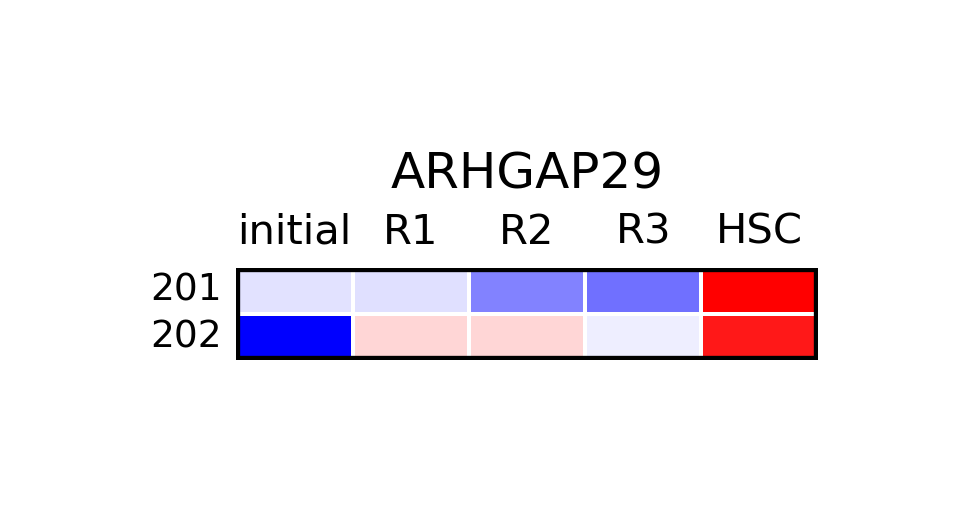

In [119]:
df_filt.columns = df_filt.columns.str.split('-').str[-1]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, len(df_filt.columns) * 0.2 #2.5

fig, ax = plt.subplots()

sns.heatmap(
    df_z.T,
    # df.T,
    cmap='bwr_r',
    center=0,
    vmin=-1.5,
    vmax=1.5,
    lw=0.5,
    linecolor='white',
    cbar=False,
    # cbar_kws={'label':'expression', 'shrink': 0.6, 'pad': 0.05},
    ax=ax,
)

plt.ylabel("")

n_rows, n_cols = df_filt.shape
ax.set_yticks(np.arange(n_cols) + 0.5)
ax.set_yticklabels(df_filt.columns, rotation=0, fontsize=9)

ax.set_xticks(np.arange(len(cond_order)) + 0.5)
ax.set_xticklabels(cond_order)
# ax.set_xticklabels([label_map.get(g, g) for g in cond_order])

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.tick_params(axis='both', bottom=False, left=False, top=False, pad=0.05)

ax.set_title(f'{query}')

# Add black box around matrix
n_rows, n_cols = df_filt.T.shape
rect = patches.Rectangle(
    (0, 0), n_cols, n_rows,
    linewidth=2, edgecolor='black', facecolor='none', zorder=10
)
ax.add_patch(rect)

plt.show()

In [47]:
genes = ['CD63', 'FLNA', 'RACK1', 'TEAD1', 'ARHGAP29']


def get_transcripts(queries, adata=adata):
    # allow single gene or list
    if isinstance(queries, str):
        queries = [queries]

    df = adata.var[adata.var['gene_name'].isin(queries)].copy()

    columns = [
        'gene_name',
        'gene_type',
        'transcript_name',
        'transcript_type',
        'uniprot',
    ]
    return df[columns]


label_df = get_transcripts(genes)
print(label_df.to_string(index=False))

color = label_df.index.to_list()



cond_order = ['initial', 'R1', 'R2', 'R3', 'HSC']


bdata.X = bdata.layers['norm'].copy()

pdata = bdata[cond_order, color].copy()
df = pdata.to_df()


# label_df comes from get_transcripts([...])
tx_to_gene = label_df['gene_name']

# ensure ordering matches df columns
tx_to_gene = tx_to_gene.loc[df.columns]

# ----------------------------------------
# compute per-transcript totals
# ----------------------------------------

transcript_totals = df.sum(axis=0)

# ----------------------------------------
# compute per-gene transcript fractions
# ----------------------------------------

tx_df = pd.DataFrame({
    'gene_name': tx_to_gene,
    'tx_total': transcript_totals
})

tx_df['gene_total'] = (
    tx_df.groupby('gene_name')['tx_total']
         .transform('sum')
)

tx_df['tx_frac'] = tx_df['tx_total'] / tx_df['gene_total']

# ----------------------------------------
# apply per-gene threshold
# ----------------------------------------

p = 0.1  # 10% threshold

keep_transcripts = tx_df.loc[tx_df['tx_frac'] > p].index

print(f"Keeping {len(keep_transcripts)} transcripts out of {df.shape[1]}")

# ----------------------------------------
# subset dataframe
# ----------------------------------------

df_filt = df[keep_transcripts]
display(df_filt)

# ----------------------------------------
# (optional) z-score after filtering
# ----------------------------------------

df_z = df_filt.apply(zscore, axis=0)
display(df_z.head())

gene_name      gene_type transcript_name                transcript_type    uniprot
     CD63 protein_coding        CD63-201                 protein_coding     P08962
 ARHGAP29 protein_coding    ARHGAP29-201                 protein_coding     Q52LW3
     FLNA protein_coding        FLNA-201                 protein_coding     P21333
     FLNA protein_coding        FLNA-202                 protein_coding        NaN
 ARHGAP29 protein_coding    ARHGAP29-202                 protein_coding        NaN
    RACK1 protein_coding       RACK1-201                 protein_coding     J3KPE3
     CD63 protein_coding        CD63-202                 protein_coding        NaN
     FLNA protein_coding        FLNA-206                 protein_coding A0A7P0NMY4
     FLNA protein_coding        FLNA-212                retained_intron        NaN
 ARHGAP29 protein_coding    ARHGAP29-203 protein_coding_CDS_not_defined        NaN
     FLNA protein_coding        FLNA-215                retained_intron        NaN
    

transcript_name,CD63-201,ARHGAP29-201,FLNA-201,FLNA-202,ARHGAP29-202,FLNA-212,RACK1-210,RACK1-227,TEAD1-203,TEAD1-206,CD63-214
initial,260.241154,65.540549,7.384005,5.793142,36.694903,29.671093,63.814613,906.476668,15.593458,108.388790,2294.954772
R1,2368.796783,65.807496,17.475849,53.629013,12.779215,0.000000,635.247128,349.134705,36.644672,46.747897,73.016284
R2,2110.518562,89.138624,17.586538,54.602013,12.729304,0.000000,531.146948,293.577942,45.992984,39.661831,45.758497
R3,1776.207548,94.122688,18.075083,68.332631,16.532088,0.000000,502.355051,279.282075,62.821935,60.617656,35.048027
HSC,242.983737,0.000000,0.000000,0.199549,1.197292,0.000000,2.594132,4800.874396,0.000000,0.000000,0.000000


transcript_name,CD63-201,ARHGAP29-201,FLNA-201,FLNA-202,ARHGAP29-202,FLNA-212,RACK1-210,RACK1-227,TEAD1-203,TEAD1-206,CD63-214
initial,-1.189372,0.078003,-0.650405,-1.100586,1.790596,2.0,-1.086182,-0.239231,-0.749110,1.636157,1.999328
R1,1.108235,0.085955,0.740142,0.613304,-0.277331,-0.5,1.105352,-0.557152,0.199890,-0.123780,-0.461555
R2,0.826800,0.780928,0.755394,0.648165,-0.281646,-0.5,0.706111,-0.588843,0.621317,-0.326098,-0.491744
R3,0.462515,0.929390,0.822710,1.140113,0.047170,-0.5,0.595690,-0.596997,1.379975,0.272222,-0.503606
HSC,-1.208177,-1.874277,-1.667841,-1.300996,-1.278789,-0.5,-1.320972,1.982223,-1.452072,-1.458501,-0.542423


In [48]:
tx_to_gene_filt = tx_to_gene.loc[df_filt.columns]
sorted_cols = tx_to_gene_filt.sort_values().index
df_filt = df_filt[sorted_cols]
df_z = df_z[sorted_cols]

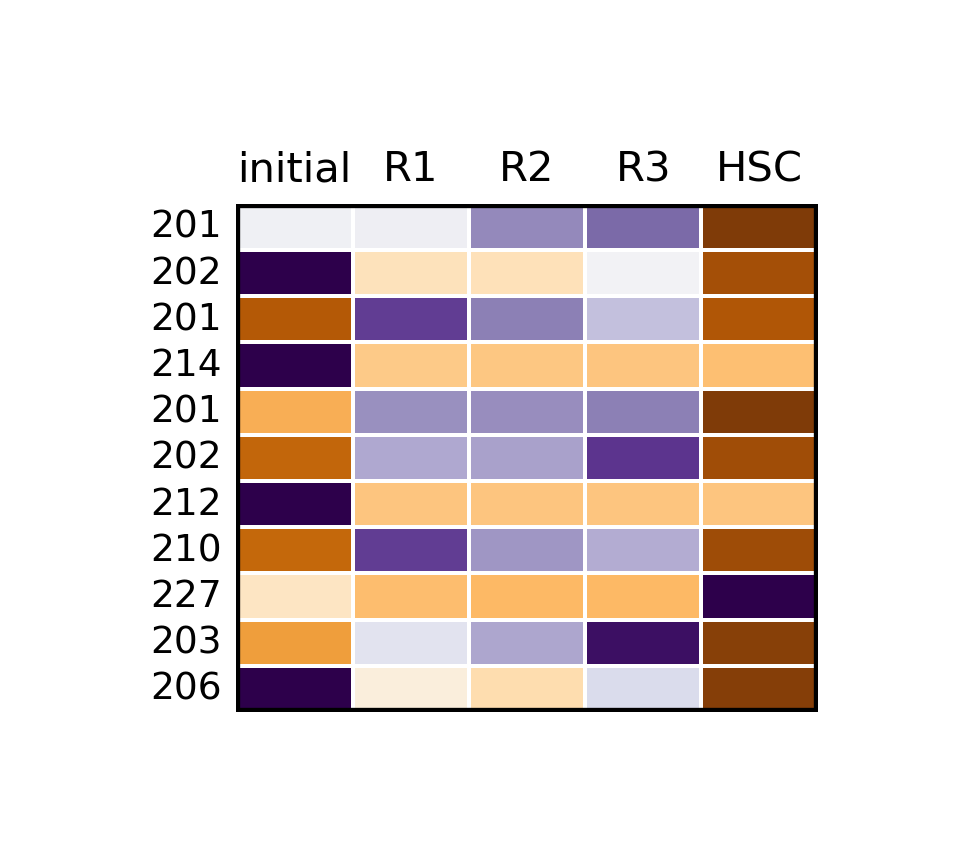

In [49]:
df_filt.columns = df_filt.columns.str.split('-').str[-1]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 2.5, len(df_filt.columns) * 0.2

fig, ax = plt.subplots()

sns.heatmap(
    df_z.T,
    cmap='PuOr',
    center=0,
    vmin=-1.5,
    vmax=1.5,
    lw=0.5,
    linecolor='white',
    cbar=False,
    ax=ax,
)

plt.ylabel("")

n_rows, n_cols = df_filt.shape
ax.set_yticks(np.arange(n_cols) + 0.5)
ax.set_yticklabels(df_filt.columns, rotation=0, fontsize=9)

ax.set_xticks(np.arange(len(cond_order)) + 0.5)
ax.set_xticklabels(cond_order)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='both', bottom=False, left=False, top=False, pad=0.05)
# ax.set_title(f'{query}')


# gene_boundaries = tx_to_gene_filt.sort_values().value_counts().cumsum()[:-1]

# for gb in gene_boundaries:
#     ax.hlines(gb, *ax.get_xlim(), color='black', linewidth=1)


# Add black box around matrix
n_rows, n_cols = df_filt.T.shape
rect = patches.Rectangle(
    (0, 0), n_cols, n_rows,
    linewidth=2, edgecolor='black', facecolor='none', zorder=10
)
ax.add_patch(rect)

plt.show()